In [4]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

print("Successful!")

Successful!


In [5]:
PROJECT_ROOT = Path("..")

TRAIN_PATH = PROJECT_ROOT / "dataset" / "raw" / "asl_alphabet_train"

image_path = next((TRAIN_PATH / "A").glob("*"))

print(image_path)

..\dataset\raw\asl_alphabet_train\A\A1.jpg


In [6]:
image = cv2.imread(str(image_path))

print("Shape:", image.shape)

Shape: (200, 200, 3)


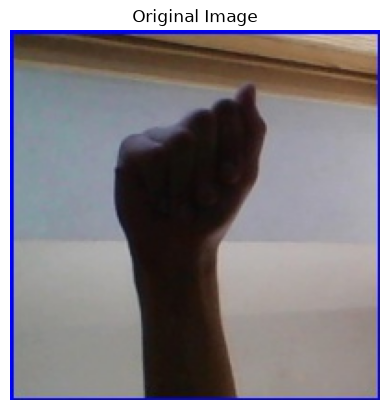

In [7]:
#open cv reads images in BGR and mediapipe reads it in RGB 
#So we convert it 
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [8]:
results = hands.process(image_rgb)

print(results.multi_hand_landmarks)

[landmark {
  x: 0.457428038
  y: 0.583321
  z: -6.47400725e-007
}
landmark {
  x: 0.570786357
  y: 0.5034284
  z: -0.0355798
}
landmark {
  x: 0.640131116
  y: 0.373975933
  z: -0.044406537
}
landmark {
  x: 0.651733875
  y: 0.264574856
  z: -0.0550684966
}
landmark {
  x: 0.634490609
  y: 0.179893553
  z: -0.0590976775
}
landmark {
  x: 0.545696914
  y: 0.270556211
  z: -0.00423305808
}
landmark {
  x: 0.586574078
  y: 0.209667951
  z: -0.0716262534
}
landmark {
  x: 0.592391729
  y: 0.307403505
  z: -0.111358792
}
landmark {
  x: 0.589894652
  y: 0.393817753
  z: -0.122083895
}
landmark {
  x: 0.467299581
  y: 0.282378
  z: -0.00464758743
}
landmark {
  x: 0.517436743
  y: 0.234142959
  z: -0.0775062814
}
landmark {
  x: 0.530205131
  y: 0.349560589
  z: -0.0962087959
}
landmark {
  x: 0.534969091
  y: 0.438434869
  z: -0.0864398479
}
landmark {
  x: 0.39551264
  y: 0.304352134
  z: -0.0160673261
}
landmark {
  x: 0.457142711
  y: 0.292900413
  z: -0.0848888382
}
landmark {
  x: 0.4

d:\Code FIles\VS code files\Project\sign-language-translator\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


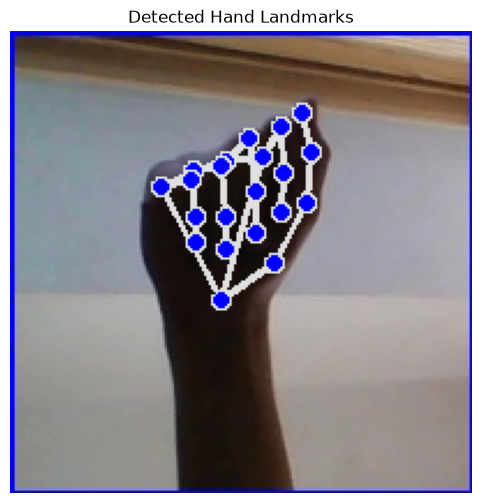

In [9]:
annotated = image_rgb.copy()

if results.multi_hand_landmarks:
    
    for hand_landmarks in results.multi_hand_landmarks:
        
        mp_draw.draw_landmarks(
            annotated,
            hand_landmarks,
            mp_hands.HAND_CONNECTIONS
        )

plt.figure(figsize=(6,6))
plt.imshow(annotated)
plt.title("Detected Hand Landmarks")
plt.axis("off")
plt.show()

In [10]:
hand_landmarks = results.multi_hand_landmarks[0]

print(type(hand_landmarks))

<class 'mediapipe.framework.formats.landmark_pb2.NormalizedLandmarkList'>


In [11]:
print(hand_landmarks.landmark[0])

x: 0.457428038
y: 0.583321
z: -6.47400725e-007



In [12]:
for i, landmark in enumerate(hand_landmarks.landmark):
    print(
        f"Landmark {i}: "
        f"x={landmark.x:.4f}, "
        f"y={landmark.y:.4f}, "
        f"z={landmark.z:.4f}"
    )

Landmark 0: x=0.4574, y=0.5833, z=-0.0000
Landmark 1: x=0.5708, y=0.5034, z=-0.0356
Landmark 2: x=0.6401, y=0.3740, z=-0.0444
Landmark 3: x=0.6517, y=0.2646, z=-0.0551
Landmark 4: x=0.6345, y=0.1799, z=-0.0591
Landmark 5: x=0.5457, y=0.2706, z=-0.0042
Landmark 6: x=0.5866, y=0.2097, z=-0.0716
Landmark 7: x=0.5924, y=0.3074, z=-0.1114
Landmark 8: x=0.5899, y=0.3938, z=-0.1221
Landmark 9: x=0.4673, y=0.2824, z=-0.0046
Landmark 10: x=0.5174, y=0.2341, z=-0.0775
Landmark 11: x=0.5302, y=0.3496, z=-0.0962
Landmark 12: x=0.5350, y=0.4384, z=-0.0864
Landmark 13: x=0.3955, y=0.3044, z=-0.0161
Landmark 14: x=0.4571, y=0.2929, z=-0.0849
Landmark 15: x=0.4692, y=0.4007, z=-0.0749
Landmark 16: x=0.4687, y=0.4721, z=-0.0444
Landmark 17: x=0.3257, y=0.3351, z=-0.0306
Landmark 18: x=0.3912, y=0.3211, z=-0.0702
Landmark 19: x=0.4049, y=0.4043, z=-0.0554
Landmark 20: x=0.4038, y=0.4576, z=-0.0289


In [13]:
features = []

for landmark in hand_landmarks.landmark:

    features.extend([
        landmark.x,
        landmark.y,
        landmark.z
    ])

print("Total Features:", len(features))

Total Features: 63


In [15]:
features[:15]

[0.4574280381202698,
 0.5833209753036499,
 -6.474007250290015e-07,
 0.5707863569259644,
 0.5034283995628357,
 -0.035579800605773926,
 0.6401311159133911,
 0.373975932598114,
 -0.04440653696656227,
 0.6517338752746582,
 0.2645748555660248,
 -0.055068496614694595,
 0.6344906091690063,
 0.17989355325698853,
 -0.05909767746925354]